# Data understanding: credit-card fraud

The goal is to understand the dataset structure, data quality, class imbalance, and a few signals that may be useful for fraud detection.

> **Dataset note:** `Class = 1` means fraud and `Class = 0` means a legitimate transaction. `Time` is measured in seconds from the first recorded transaction; `V1`–`V28` are anonymised PCA-transformed features, so they should be analysed statistically rather than interpreted as business variables.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid", context="notebook")
CLASS_LABELS = {0: "Legitimate", 1: "Fraud"}
CLASS_PALETTE = {"Legitimate": "#4C78A8", "Fraud": "#E45756"}

## 1. Load and inspect the data

Check the first rows, shape, columns, types, and summary statistics before making assumptions about the data.

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 2. Data-quality checks

Missing values and duplicate records can affect later modelling. For this learning notebook, we only measure them here; a final modelling workflow should make a deliberate duplicate-handling decision.

In [7]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(1081)

## 3. Target distribution — the key modelling challenge

Fraud is rare. A standard accuracy score can look excellent while missing most fraud cases, so later prefer precision, recall, F1, PR-AUC, and a carefully chosen decision threshold.

The chart uses a logarithmic y-axis so that the much smaller fraud class remains visible.

In [10]:
class_counts = (
    df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Transactions")
)
class_counts["Class"] = class_counts["Class"].map(CLASS_LABELS)
class_counts

,Class,Transactions
0,Legitimate,284315
1,Fraud,492


In [11]:
class_counts.assign(Percentage=lambda data: data["Transactions"] / len(df) * 100)

,Class,Transactions,Percentage
0,Legitimate,284315,99.827251
1,Fraud,492,0.172749


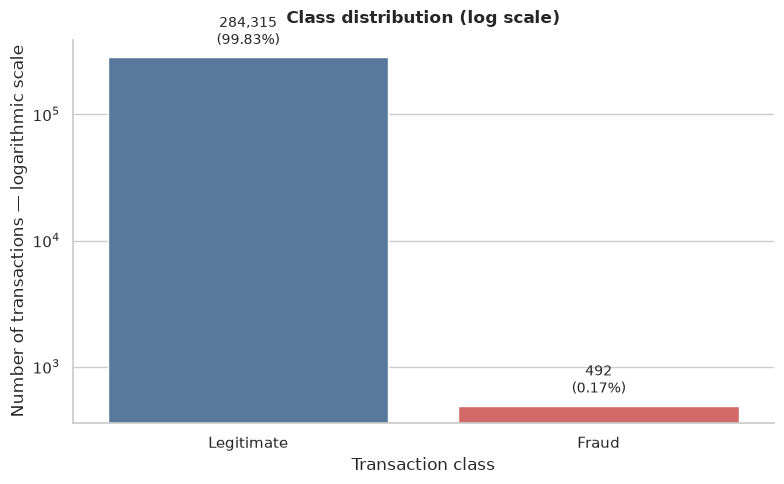

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=class_counts, x="Class", y="Transactions", hue="Class",
            palette=CLASS_PALETTE, legend=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Class distribution (log scale)", pad=12, weight="bold")
ax.set_xlabel("Transaction class")
ax.set_ylabel("Number of transactions — logarithmic scale")
for bar, (_, row) in zip(ax.patches, class_counts.iterrows()):
    ax.annotate(f"{row['Transactions']:,}\n({row['Transactions'] / len(df):.2%})",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", xytext=(0, 6), textcoords="offset points", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## 4. When do transactions occur?

Time is converted to an hour within the recorded period. The next plot normalises each class to percentages, making the *shape* of legitimate and fraudulent activity comparable despite their very different counts. This is not a real calendar hour or customer time zone.

In [13]:
df["Hour"] = (df["Time"] / 3600) % 24

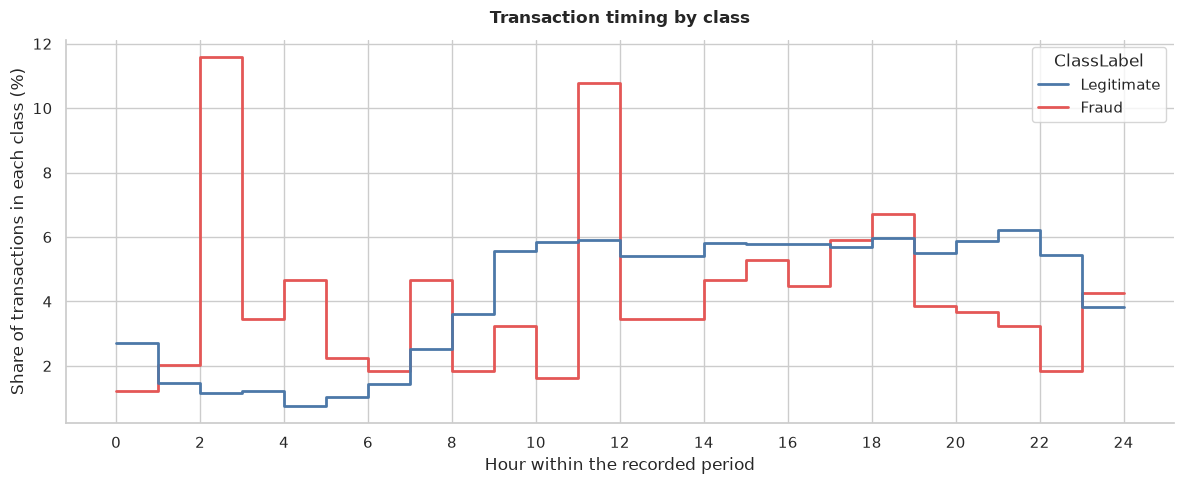

In [14]:
plot_data = df.assign(ClassLabel=df["Class"].map(CLASS_LABELS))
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=plot_data, x="Hour", hue="ClassLabel", hue_order=["Legitimate", "Fraud"],
             bins=np.arange(25), stat="percent", common_norm=False, multiple="layer",
             element="step", fill=False, linewidth=2, palette=CLASS_PALETTE, ax=ax)
ax.set_title("Transaction timing by class", pad=12, weight="bold")
ax.set_xlabel("Hour within the recorded period")
ax.set_ylabel("Share of transactions in each class (%)")
ax.set_xticks(range(0, 25, 2))
sns.despine()
plt.tight_layout()
plt.show()

## 5. Transaction amounts

Amounts are usually heavily right-skewed. Log-based views make small and large values readable in the same chart, while the descriptive statistics keep the original amount scale.

In [15]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


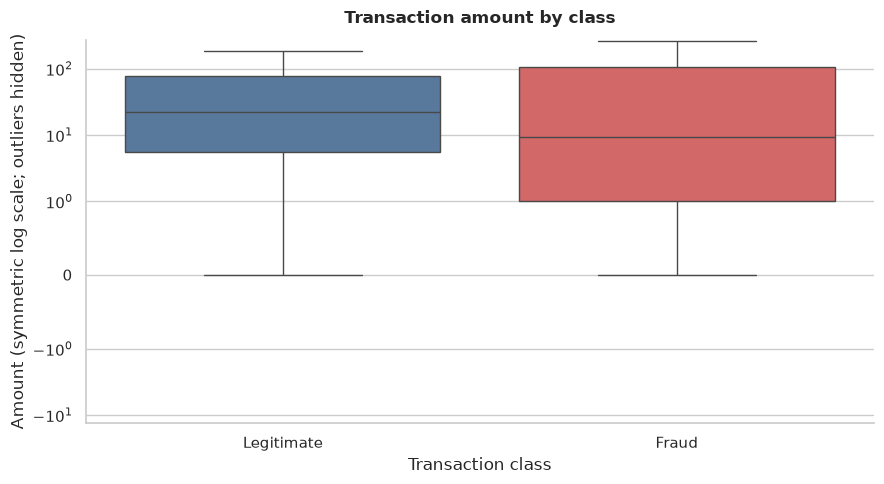

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=plot_data, x="ClassLabel", y="Amount", hue="ClassLabel",
            order=["Legitimate", "Fraud"], palette=CLASS_PALETTE, legend=False,
            showfliers=False, ax=ax)
ax.set_yscale("symlog", linthresh=1)
ax.set_title("Transaction amount by class", pad=12, weight="bold")
ax.set_xlabel("Transaction class")
ax.set_ylabel("Amount (symmetric log scale; outliers hidden)")
sns.despine()
plt.tight_layout()
plt.show()

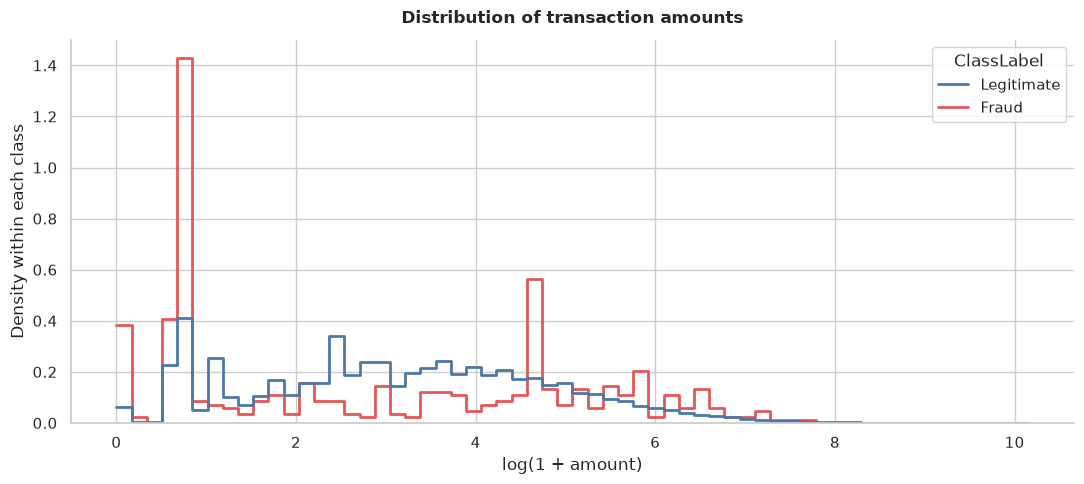

In [17]:
amount_plot_data = plot_data.assign(LogAmount=np.log1p(plot_data["Amount"]))
fig, ax = plt.subplots(figsize=(11, 5))

sns.histplot(data=amount_plot_data, x="LogAmount", hue="ClassLabel",
             hue_order=["Legitimate", "Fraud"], bins=60, element="step", fill=False,
             stat="density", common_norm=False, linewidth=2, palette=CLASS_PALETTE, ax=ax)
ax.set_title("Distribution of transaction amounts", pad=12, weight="bold")
ax.set_xlabel("log(1 + amount)")
ax.set_ylabel("Density within each class")
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
df.groupby("Class").agg(
    avg_amount=("Amount", "mean"),
    median_amount=("Amount", "median"),
    max_amount=("Amount", "max"),
    std_amount=("Amount", "std")
)

,avg_amount,median_amount,max_amount,std_amount
Class,,,,
0,88.291022,22.00,25691.16,250.105092
1,122.211321,9.25,2125.87,256.683288


## 6. Correlations

The heatmap is a broad scan for linear relationships. Correlation does not show causation and can miss non-linear patterns; it is simply a useful first diagnostic before feature selection and modelling.

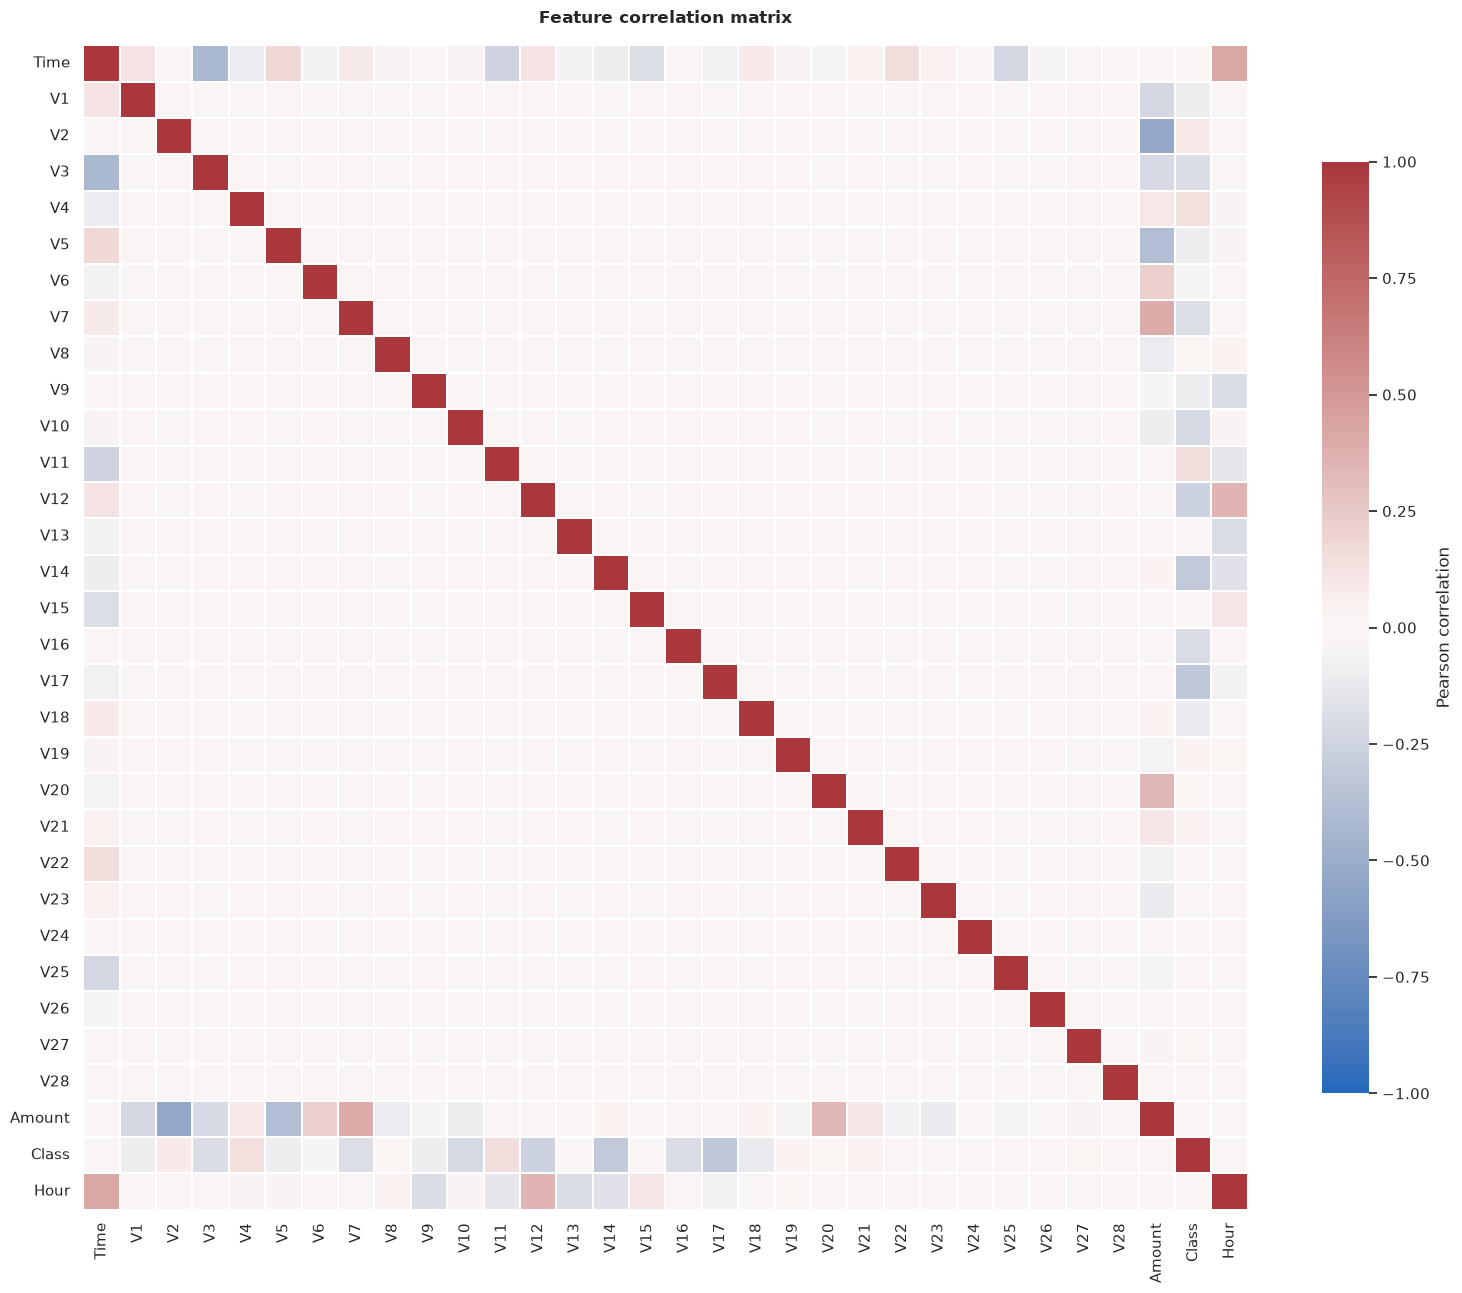

In [19]:
plt.figure(figsize=(16, 13))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8}
)

plt.title("Feature correlation matrix", pad=16, weight="bold")
plt.tight_layout()
plt.show()